In [1]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast




In [2]:
# --- User toggle ---
Cristina = False
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
    base_dir = '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output'
    
elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"
    base_dir = '/lustre/lrspec/metrics/results'

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Shar's Dirac server setup


In [31]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "local_MDwarfFlares_metric"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")




[INFO] Loaded metric module: local_MDwarfFlares_metric
[INFO] Loaded shared_utils module


In [29]:
#metric configurations
use_kcorrect=False
testname=None  
#use this to add text to the filename
#if you're testing template or population variables other than the below variables

testname_metric_only=None 
#use this to add text to the filename for the observation record df only (does not change pop/template filenames)
#so for anything you're changing that's only about the detection criteria

#control whether we generate new files - 
#new files will still generate if these are false and it can't find a file with the correct parameters
#so recommend leaving it on false
generate_new_templates = True 
generate_new_pop = True
make_debug_plots = True #toggle whether or not the pop generation makes plots

#population variables
rate_density = 1e-9

# apply None for non-use case 
z_min, z_max = .00226, .3
d_min, d_max = None, None #3000, 4000

#other
gal_lat_cut = 30 #latitude cut, for Galactic phenomena
use_extinction = True
t_start = 1 #start time in days
t_end = 3652

# Whether to remove Metric_temp_* folders after running
clean_temp = True  # <- NEW toggle

#cadence variables
cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs','noroll_v3.6_10yrs']
ignore_triples = False #turn this to true to ignore triples

# Standardized output paths for this science case
# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="MDwarfFlares", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths

MDwarfFlares_den_1e-09_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_kcor_None_None


In [32]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Generating 1000 light curve templates.
Saved synthetic light curve templates to /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_1e-09_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_kcor_None_None_templates.pkl
Loaded flare templates from /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_1e-09_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_kcor_None_None_templates.pkl


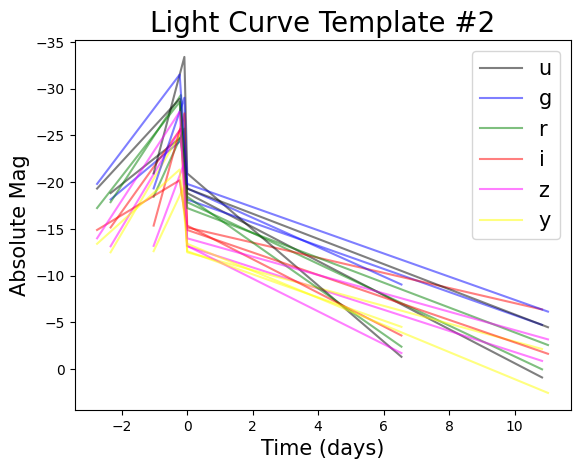

In [33]:
#plot light curves from pkl file if desired
ylim = None
use_log_time = False
plot_overlap = True
shared_utils.plot_some_lcs_from_pkl(templates_file, num=3, use_log_time = use_log_time,plot_overlap=plot_overlap,ylim=ylim)

[INFO] Generating population and saving to /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_1e-09_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_kcor_None_None_population.pkl
[INFO] z_min = 0.00226 → d_min = 10.008475172186685 Mpc
[INFO] z_max = 0.30000 → d_max = 1232.706667272352888 Mpc
Simulated 70 events using rate_density = 1.0e-09
Len ra before masking:  70
b:  [ 31.42221553 -69.77132472 -42.30667511  10.30782303  50.52184256
  16.96363161  55.10656623  20.08939297  -9.89506244  56.19023266
  55.86014613 -44.56802204  -5.48770211  21.63978562 -20.41199937
  16.82257981 -64.63629316  59.69884969  -7.9984273  -50.64162939
  60.61462806  36.77452313  77.2323434  -56.76878577  28.0612225
 -59.24100037  12.78610568  19.2131013  -23.8717635   50.97738907
 -52.68961328 -21.80175374  -7.04966186 -61.17322487 -64.65215902
  -0.21364454  15.23579299   8.62507568  57.67680052  -4.21728034
   3.18096787 -83.16860059 -77.98241503  75.11616562  35.97508246
 -12.54289969 -54.52965815 -29

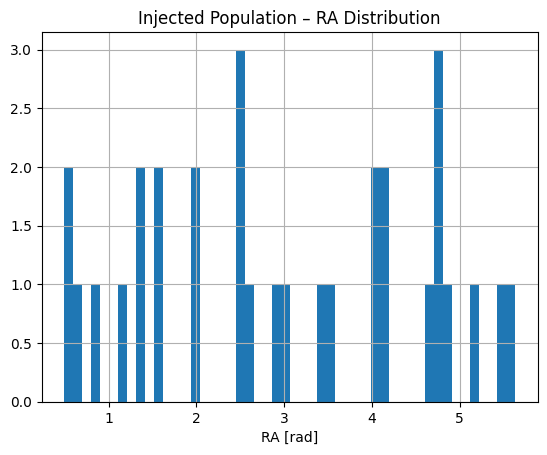

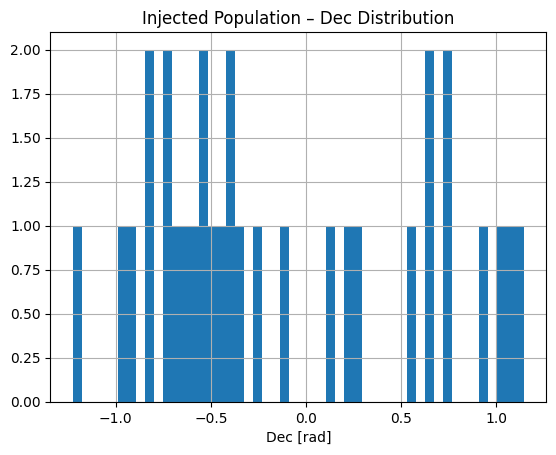

initial peak times:  [3533.37803312 1190.58838256 1353.54838673 1715.34826697  692.75993202
  475.34341598 1737.79868565  829.44603338 2446.49089459 1597.0416558
 3041.10809381 2557.66788741 1141.45060769 3039.58053489 2939.19466922
 1415.68356184 1053.68590745 2492.79108501  511.23631766  730.86484724
   27.87964686 2874.06090226 2428.37047742 2575.55879736 2851.44169226
 1676.50149649 2077.47410642  511.39884016  419.14929848 2441.3392135
 1720.97224863]
gal_lat_cut is none


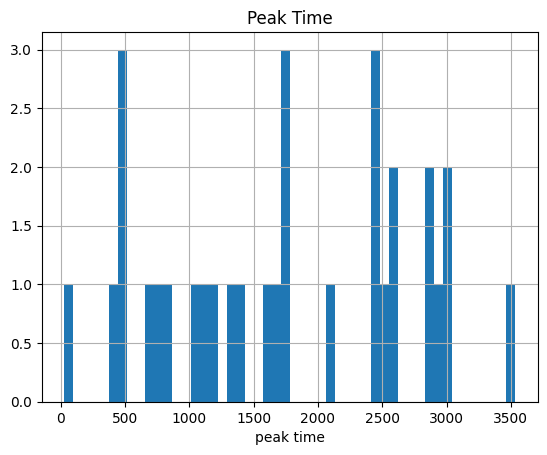

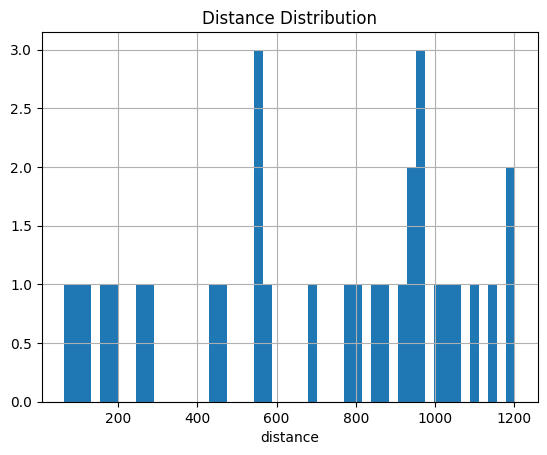

[DEBUG] coords.dec[:5]: [  7.18075578 -45.78396716 -23.31795707  36.42357364 -27.95318688] deg
[DEBUG] coords.dec.unit: deg


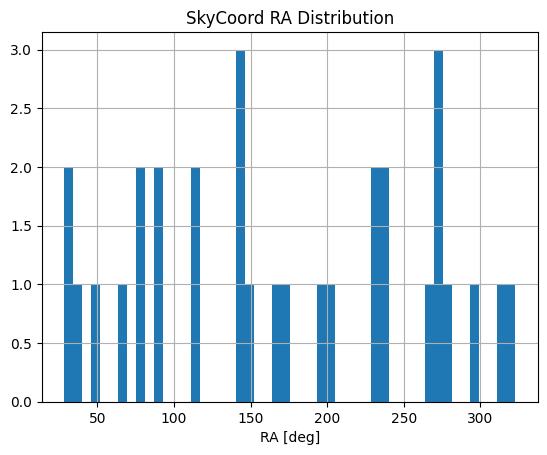

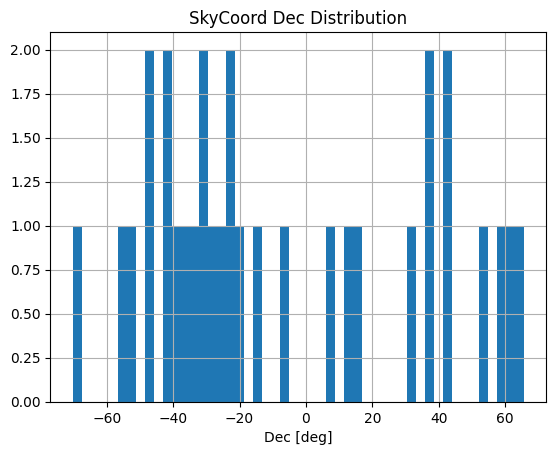

Saved population to /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_1e-09_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_kcor_None_None_population.pkl
DEBUG: type(peak_times) = <class 'numpy.ndarray'>
DEBUG: shape(peak_times) = (31,)


In [34]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=1000,
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots
)


## All 10 years


--- Running four_roll_v4.3.1_10yrs ---
EBV included

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 204
mag_obs         | type: <class 'list'> | length: 204
snr_obs         | type: <class 'list'> | length: 204
filter          | type: <class 'list'> | length: 204
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
sid             | type: <class 'numpy.int64'> | value: 0
file_indx       | type: <class 'numpy.int64'> | value: 855
ra              | type: <class 'numpy.float64'> | value: 4.798291904506286
dec             | type: <class 'numpy.float64'> | value: 0.12532783116806523
distance_Mpc    | type: <class 'numpy.float64'> | value: 956.3231365065515
peak_mjd_observed | type: <class 'numpy.float64'> | value: 64523.12887898585
peak_mag_observed | type: <class 'numpy.float64'> | value: 43.3726260652728
ebv             | type: <class 'numpy.float32'> | value: 0.2313084453344345
peak_tim

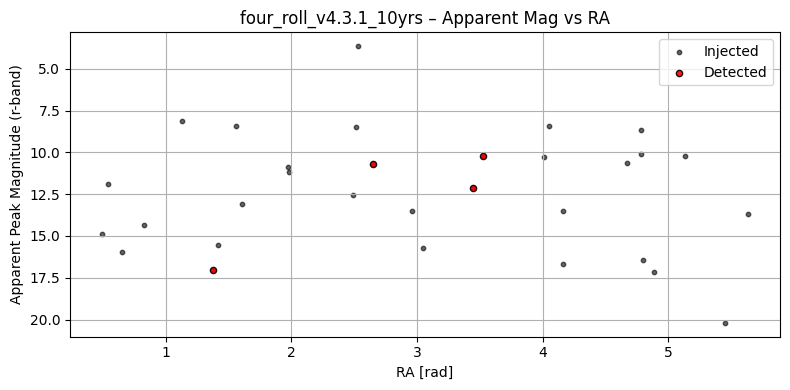

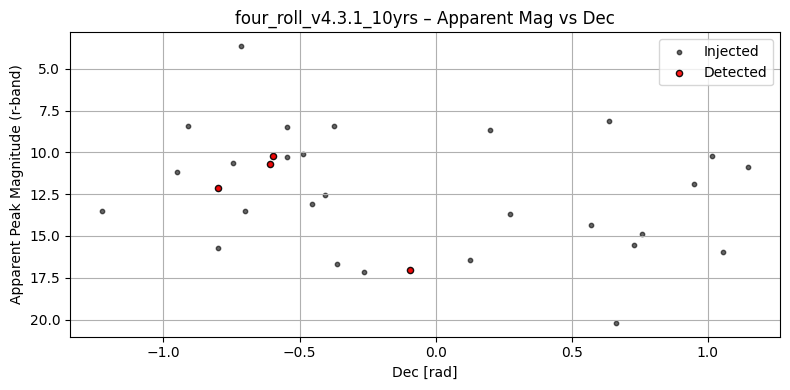

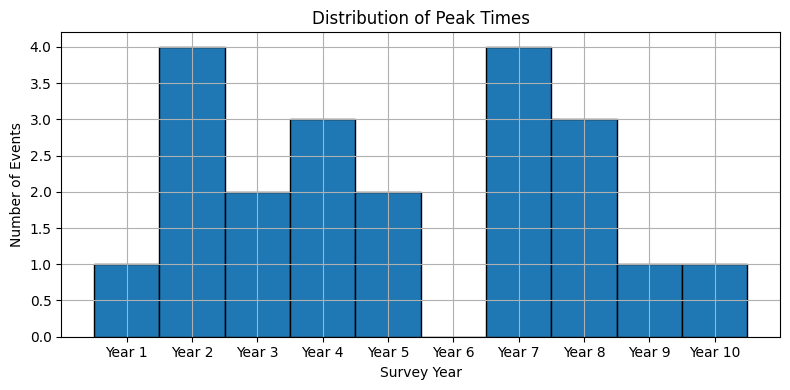

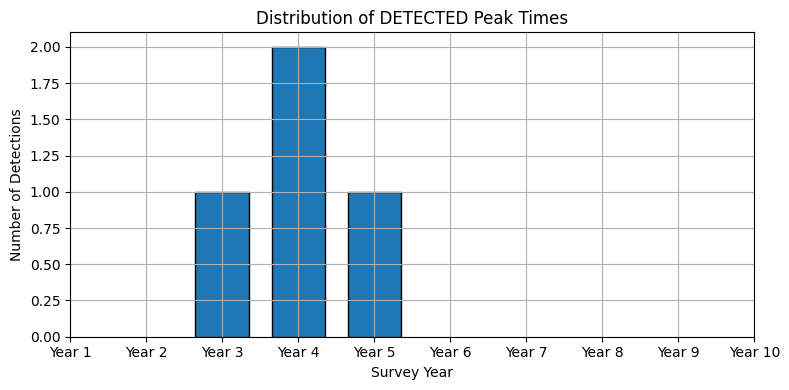

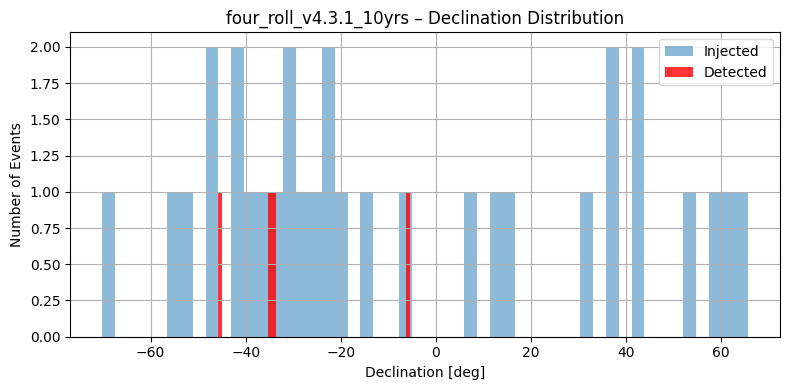

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_four_roll_v4.3.1_10yrs

--- Running baseline_v4.3.1_10yrs ---
EBV included

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 195
mag_obs         | type: <class 'list'> | length: 195
snr_obs         | type: <class 'list'> | length: 195
filter          | type: <class 'list'> | length: 195
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
sid             | type: <class 'numpy.int64'> | value: 0
file_indx       | type: <class 'numpy.int64'> | value: 855
ra              | type: <class 'numpy.float64'> | value: 4.798291904506286
dec             | type: <class 'numpy.float64'> | value: 0.12532783116806523
distance_Mpc    | type: <class 'numpy.float64'> | value: 956.3231365065515
peak_mjd_observed | type: <class 'numpy.float64'> | value: 61657.061968039394
peak_mag_observed | type: <class 'numpy.float6

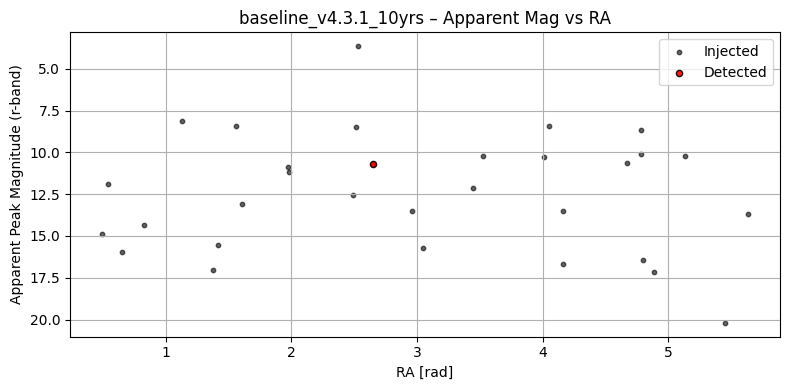

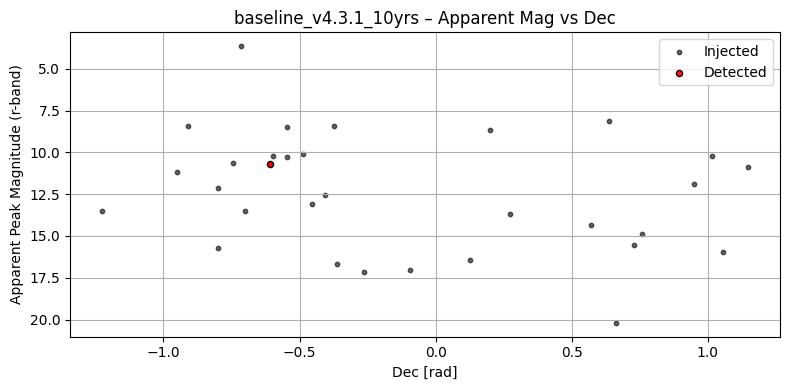

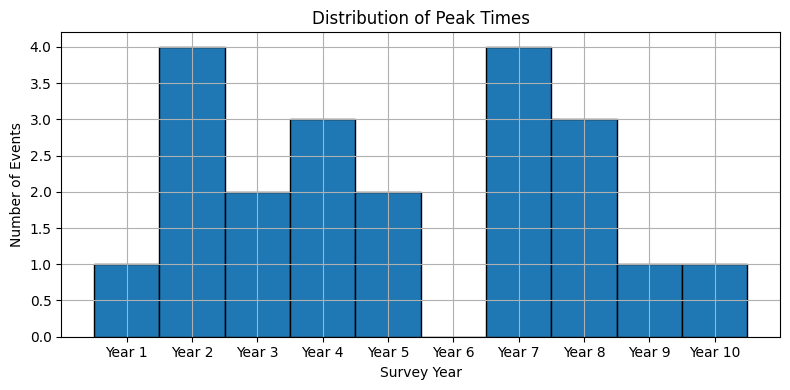

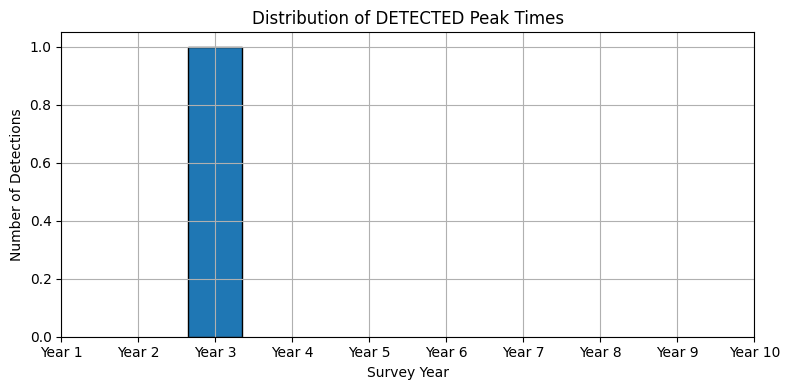

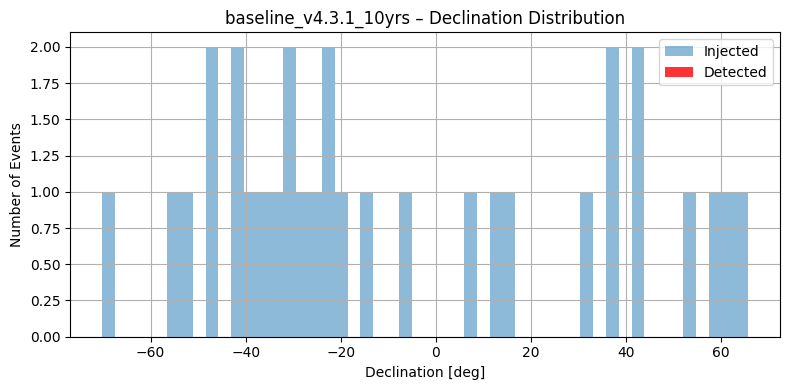

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v4.3.1_10yrs

--- Running noroll_v3.6_10yrs ---
EBV included


OperationalError: (sqlite3.OperationalError) no such table: displays
[SQL: SELECT displays.display_id AS displays_display_id, displays.metric_id AS displays_metric_id, displays.display_group AS displays_display_group, displays.display_subgroup AS displays_display_subgroup, displays.display_order AS displays_display_order, displays.display_caption AS displays_display_caption 
FROM displays 
WHERE displays.metric_id = ?]
[parameters: (1,)]
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [35]:
#run detection metric
df_obs = shared_utils.run_detect(metric, slicer, cadences,  shared_lc_model, db_dir, storage_dir, df_file, use_kcorrect=False,ignore_triples=ignore_triples, debug=True, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [39]:
importlib.reload(metric)

<module 'local_MDwarfFlares_metric' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/MDwarfFlare/local_MDwarfFlares_metric.py'>

In [40]:
#choose what to run in run_multi_metrics
# we can remove historical if we want
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=['detect'], use_extinction=use_extinction)



--- Running four_roll_v4.3.1_10yrs ---
(1,)
EBV included
                                      Sum                     run  \
four_roll_v4.3.1_10yrs_Detect_Metric  4.0  four_roll_v4.3.1_10yrs   

                                      n_events_full_sky  
four_roll_v4.3.1_10yrs_Detect_Metric                 31  


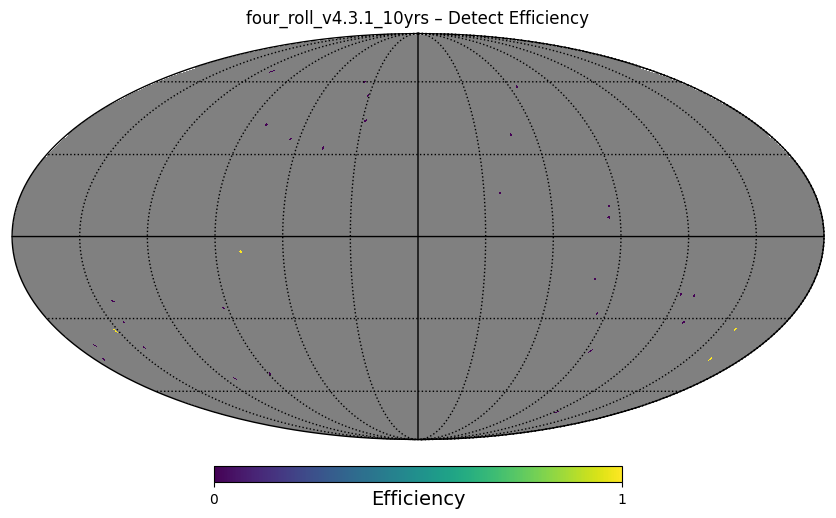

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_noroll_v3.6_10yrs

--- Running baseline_v4.3.1_10yrs ---
(1,)


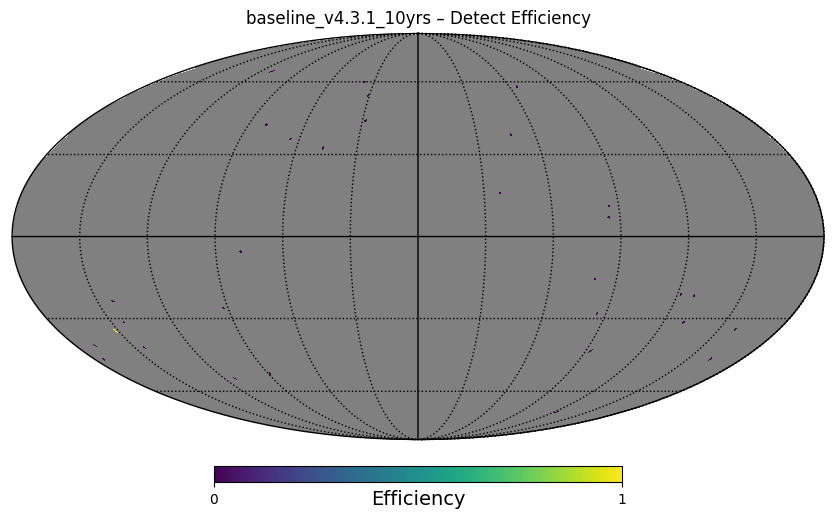

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_noroll_v3.6_10yrs

--- Running noroll_v3.6_10yrs ---
(1,)


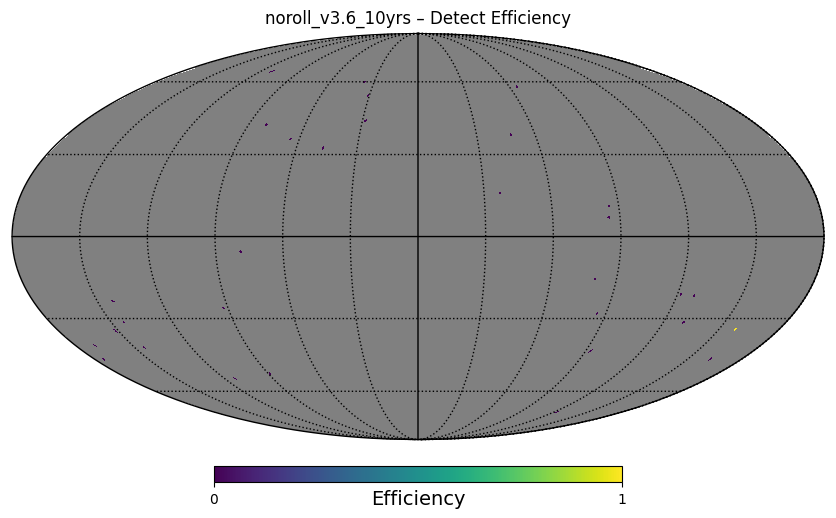

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_noroll_v3.6_10yrs
saved summary to  /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_1e-09_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_kcor_None_None_None_multi_summary.csv


In [41]:
summary_df = shared_utils.run_multi_metrics(multi_metrics, slicer, cadences, shared_lc_model, db_dir, storage_dir, summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [42]:
summary_df

,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_Detect_Metric,4.0,four_roll_v4.3.1_10yrs,31
baseline_v4.3.1_10yrs_Detect_Metric,1.0,baseline_v4.3.1_10yrs,31
noroll_v3.6_10yrs_Detect_Metric,1.0,noroll_v3.6_10yrs,31


In [321]:
# Convert to numeric safely
valid_peak_mags = pd.to_numeric(detected_df['peak_mag_observed'], errors='coerce')

# Remove NaNs and cap at 99
valid_peak_mags = valid_peak_mags[np.isfinite(valid_peak_mags) & (valid_peak_mags < 99)]

# Plot
plt.figure(figsize=(8, 4))
plt.hist(valid_peak_mags, bins=30, edgecolor='black', color='red')
plt.xlabel("Apparent Peak Magnitude")
plt.ylabel("Number of Detected GRB Afterglows")
plt.title("Distribution of Apparent Peak Magnitudes (Detected GRB Afterglows)")
plt.gca().invert_xaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'detected_df' is not defined